In [1]:
import matplotlib.pyplot as plt
import numpy as np
import io,os
import datetime as dt
from h5py import File
import pandas as pd
import netCDF4 as nc
import scipy
import glob
import pdb
import geopandas as gpd
from turfpy.measurement import boolean_point_in_polygon
from turfpy.transformation import intersect
from geojson import Point, Polygon, Feature
from cartopy import crs as ccrs
from scipy.interpolate import RectBivariateSpline,RegularGridInterpolator

In [4]:
stilt_dir = '/scratch/07351/tg866507/halo/'

In [30]:
alts = [50,150,250,500,750,1000,1500,2000,3000,4000,5000,7500,10000]
wrf_fp = np.zeros((len(alts),250,312))
hrrr_fp = np.zeros((len(alts),250,312))
for iz,z in enumerate(alts):#,150,250,500,750,1000,1500,2000,3000,4000,5000,7500,10000]:
    wrf_files = sorted(glob.glob(f'{stilt_dir}/out_wrfghg/subset_obs_{z}.0/footprints/*.nc'))
    for fi in wrf_files:
        wrf_fp[iz] += File(fi)['foot'][:].sum(0)
    hrrr_files = sorted(glob.glob(f'{stilt_dir}/out_hrrr/subset_obs_{z}.0/footprints/*.nc'))
    for fi in hrrr_files:
        hrrr_fp[iz] += File(fi)['foot'][:].sum(0)

In [21]:
wrf_fp = f_wrf['foot'][:]
hrrr_fp = f_hrrr['foot'][:]

In [17]:
wrf_fp.shape

(3, 250, 312)

In [18]:
hrrr_fp.shape

(19, 250, 312)

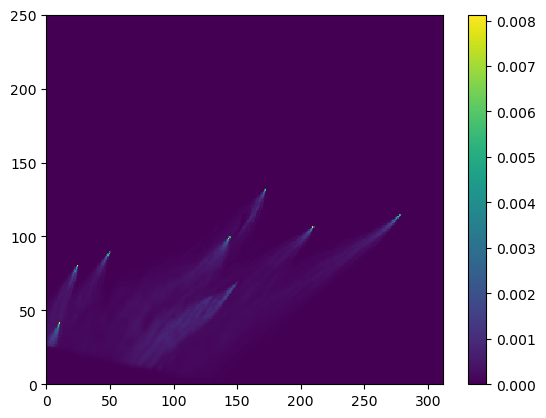

In [31]:

plt.pcolormesh(wrf_fp[2]); plt.colorbar()

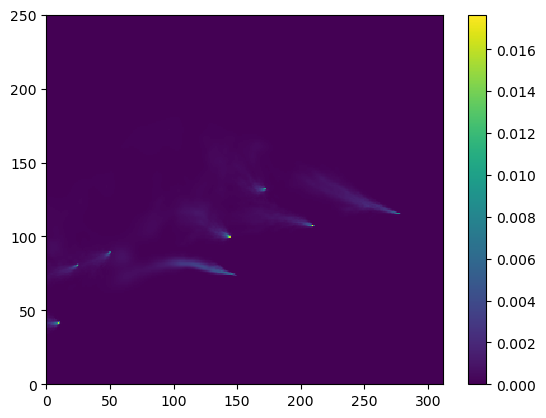

In [33]:
plt.pcolormesh(hrrr_fp[2]); plt.colorbar()